# Практическое задание №1
## Основы цифровой обработки сигналов: дискретизация, спектральный анализ, алиасинг

**Цель работы:**  
- Освоить базовые приёмы работы с библиотеками NumPy и Matplotlib в Jupyter Notebook.  
- Научиться генерировать различные типы сигналов и анализировать их спектры с помощью быстрого преобразования Фурье (БПФ).  
- Изучить эффект алиасинга и научиться правильно выбирать частоту дискретизации.  

**Необходимое ПО:**  
- Python 3 с установленными пакетами `numpy`, `matplotlib`, `scipy`, `ipywidgets` (для интерактива).  
- Jupyter Notebook / Google Colab.  

**Формат сдачи:**  
- Один Jupyter Notebook с выполненными заданиями, содержащий код, графики и текстовые ответы на вопросы.  
- Имя файла: `1_Фамилия.ipynb`.

## Часть 1. Знакомство с инструментарием

### 1.1. Импорт библиотек и создание временной оси

Выполните в первой ячейке:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import ipywidgets as widgets
from IPython.display import display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

Создайте временную ось для сигнала длительностью 1 секунду с частотой дискретизации 1000 Гц (т.е. 1000 отсчётов в секунду). Выведите длину массива времени и шаг дискретизации.

In [2]:
fs = 1000 # частота дискретизации, Гц
T = 1              # длительность сигнала, с
t = []  # временная ось
t = np.linspace(0, T, fs * T, endpoint=False)
print(f"Длина массива времени: {len(t)} отсчётов")
print(f"Шаг дискретизации (период): {t[1] - t[0]:.5f} с")


Длина массива времени: 1000 отсчётов
Шаг дискретизации (период): 0.00100 с


**Вопрос 1:** Чему равен период дискретизации $T_s$? Как связаны частота дискретизации $f_s$ и период $T_s$?

Период дискретизации равен {0.001 с}. Частота и период связаны {Ts = 1/fs}

### 1.2. Генерация простых сигналов

Сгенерируйте и визуализируйте:
- Синусоидальный сигнал частотой 5 Гц, амплитудой 1.
- Сумму двух синусоид с частотами 5 и 12 Гц и одинаковыми амплитудами.
- Прямоугольный меандр частотой 2 Гц (используйте `signal.square`).

Для каждого сигнала постройте график временной зависимости (первые 0.5 секунды).

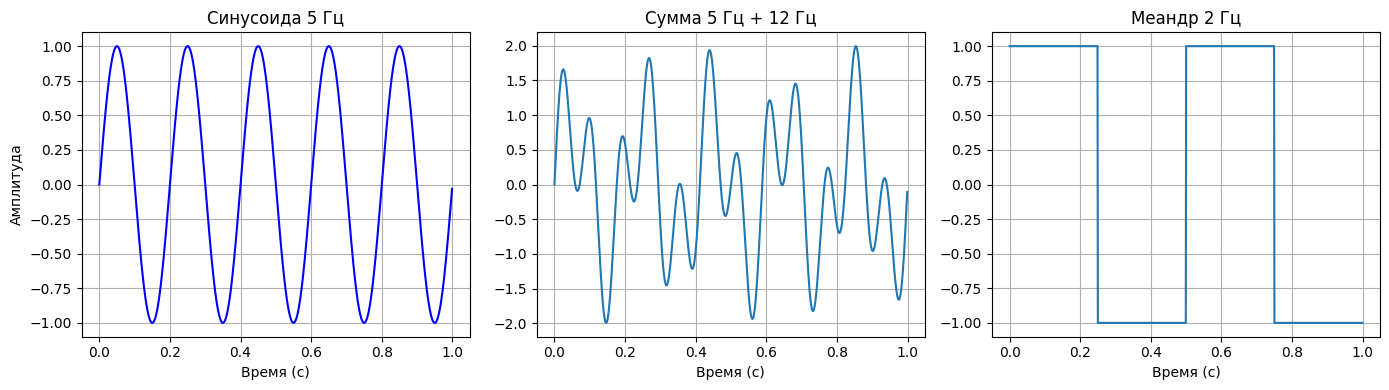

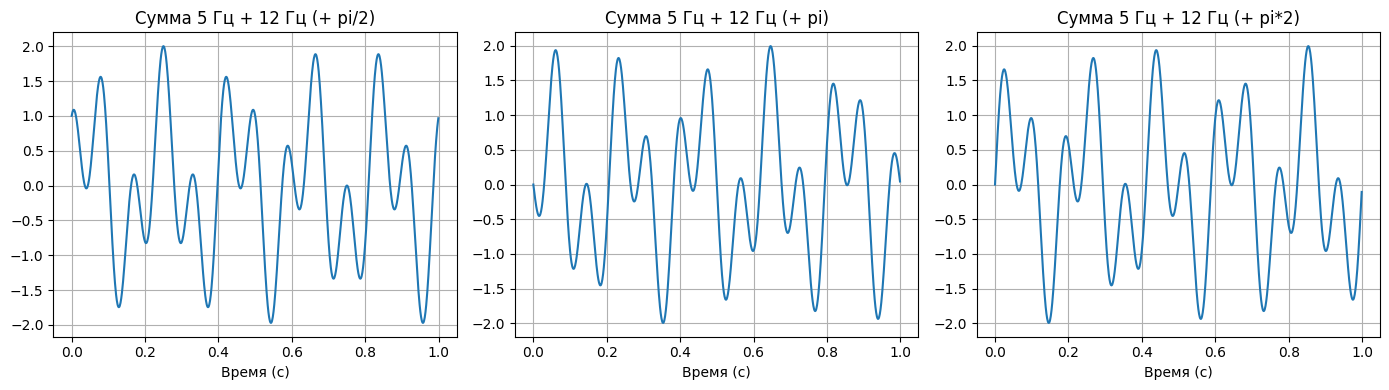

In [3]:
# Синусоида 5 Гц
f1 = 5
A1 = 1
phi = 0
sin5 = A1 * np.sin(2 * np.pi * f1 * t + phi)

# Сумма синусоид 5 и 12 Гц
f2 = 12
A2 = 1
sin12 = A2 * np.sin(2 * np.pi * f2 * t + 0)
sum_sin = sin5 + sin12

# Меандр 2 Гц
f_m = 2
meander = signal.square(2 * np.pi * f_m * t)

# Визуализация
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(t, sin5, '-b')  # первые 0.5 с
plt.title('Синусоида 5 Гц')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(t, sum_sin)
plt.title('Сумма 5 Гц + 12 Гц')
plt.xlabel('Время (с)')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(t, meander)
plt.title('Меандр 2 Гц')
plt.xlabel('Время (с)')
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))

# Сумма синусоид 5 и 12 Гц (+ pi/2)
f2 = 12
A2 = 1
sin12 = A2 * np.sin(2 * np.pi * f2 * t + np.pi/2)
sum_sin = sin5 + sin12

plt.subplot(1, 3, 1)
plt.plot(t, sum_sin)
plt.title('Сумма 5 Гц + 12 Гц (+ pi/2)')
plt.xlabel('Время (с)')
plt.grid(True)

# Сумма синусоид 5 и 12 Гц (+ pi)
f2 = 12
A2 = 1
sin12 = A2 * np.sin(2 * np.pi * f2 * t + np.pi)
sum_sin = sin5 + sin12

plt.subplot(1, 3, 2)
plt.plot(t, sum_sin)
plt.title('Сумма 5 Гц + 12 Гц (+ pi)')
plt.xlabel('Время (с)')
plt.grid(True)

# Сумма синусоид 5 и 12 Гц (+ pi*2)
f2 = 12
A2 = 1
sin12 = A2 * np.sin(2 * np.pi * f2 * t + np.pi * 2)
sum_sin = sin5 + sin12

plt.subplot(1, 3, 3)
plt.plot(t, sum_sin)
plt.title('Сумма 5 Гц + 12 Гц (+ pi*2)')
plt.xlabel('Время (с)')
plt.grid(True)

plt.tight_layout()
plt.show()


**Вопрос 2:** Изменится ли вид суммы синусоид, если одну из них сдвинуть по фазе на 90° ($\pi/2$), на 180° ($\pi$), на 360° ($2\pi$)? (Проверьте на практике, изменив фазу второго сигнала). Объясните результат.

Вид суммы синусоид изменяется, если одну из них сдвинуть по фазе на {pi / 2 и pi}, и не изменяется, если сдвинуть на {2 * pi}. Это происходит, поскольку {при приращении аргумента на pi/2 согласно формулам приведения получаем функцию косинуса с аргументом, равным исходному графику. А в случае приращения аргумента на pi получаем исходную функцию, взятую с минусом, то есть её график будет симметричен исходному по оси y.}

## Часть 2. Спектральный анализ с помощью БПФ

### 2.1. Спектр синусоиды

Для синусоиды частотой 5 Гц вычислите БПФ (`np.fft.fft`). Постройте амплитудный спектр (модуль БПФ) для положительных частот. Не забудьте правильно нормировать амплитуды (поделить на количество отсчётов и учесть, что мы берём половину спектра). Частотную ось получите с помощью `np.fft.fftfreq`.

Подпишите оси: частота (Гц), амплитуда.

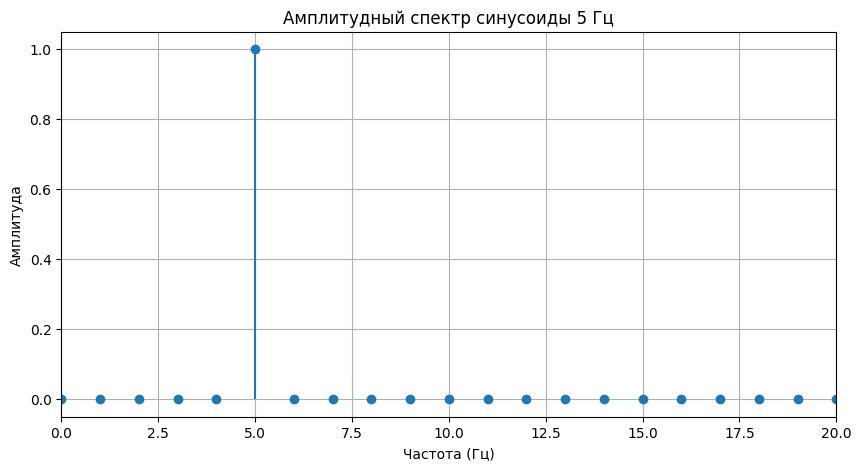

In [4]:


# БПФ синусоиды 5 Гц
N = len(sin5)
X = np.fft.fft(sin5)
freq = np.fft.fftfreq(N, d=1/fs)

# Берём только положительные частоты
half = N//2
X_mag = np.abs(X[:half]) / half  # не забываем про нормировку амплитуды
freq_pos = freq[:half] # только положительные частоты

plt.figure(figsize=(10, 5))
plt.stem(freq_pos, X_mag, basefmt=" ")
plt.title('Амплитудный спектр синусоиды 5 Гц')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 20)
plt.grid(True)
plt.show()

**Вопрос 3:** Почему в спектре присутствует только один пик? Какая должна быть его амплитуда теоретически? Совпадает ли с полученной?

В спектре присутствует только один пик, поскольку {сигнал является чистой синусоидой с одной частотой 5 Гц.}. Его теоретическая амплитуда должна быть равна {1}. Она {совпадает} с полученной, поскольку {была корректна выполнена нормировка: взяли только положительные частоты, следовательно выполнили деление модуля БПФ на N // 2}.

### 2.2. Спектр суммы синусоид

Для суммы синусоид (5 и 12 Гц) постройте амплитудный спектр. Убедитесь, что видны два пика на ожидаемых частотах. Измерьте их амплитуды.

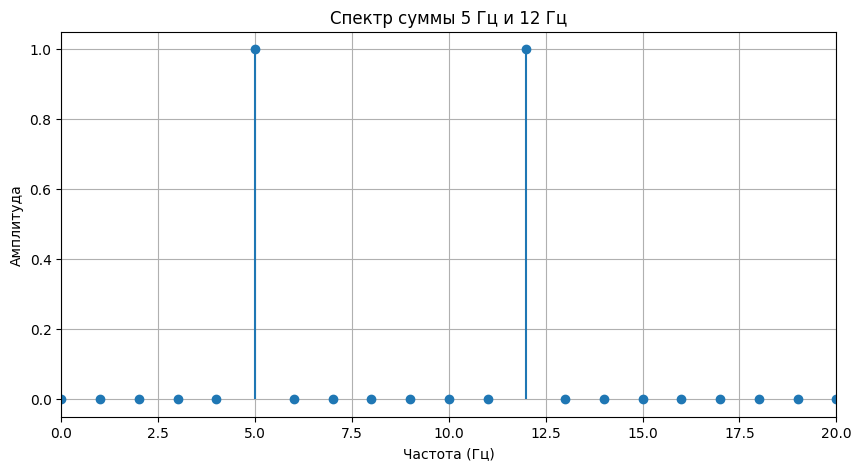

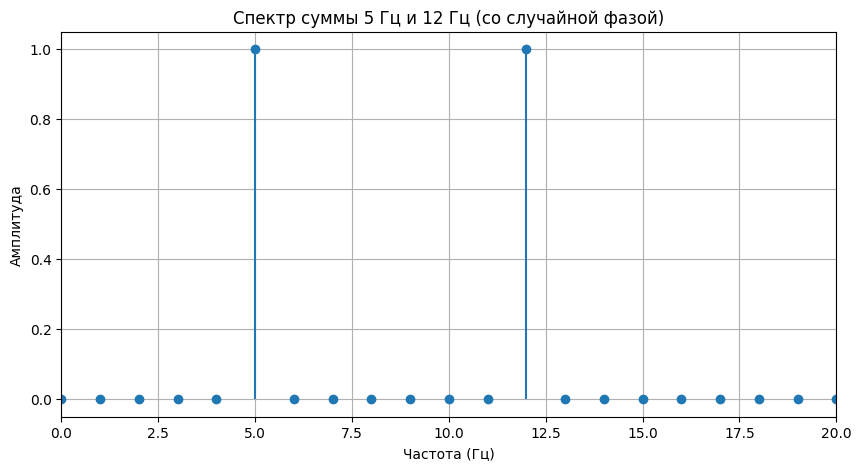

In [5]:
X_sum = np.fft.fft(sum_sin)
X_sum_mag = np.fft.fftfreq(N, d=1/fs)
X_mag = np.abs(X_sum[:half]) / half

plt.figure(figsize=(10, 5))
plt.stem(freq_pos, X_mag, basefmt=" ")
plt.title('Спектр суммы 5 Гц и 12 Гц')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 20)
plt.grid(True)
plt.show()

# задаём фазы
phi1 = 0
phi2 = np.random.uniform(0, 2*np.pi)  # случайная фаза

# синусоиды с фазами
sin5_phase = A1 * np.sin(2 * np.pi * f1 * t + phi1)
sin12_phase = A2 * np.sin(2 * np.pi * f2 * t + phi2)

# сумма сигналов
sum_sin_phase = sin5_phase + sin12_phase

# БПФ
X_sum = np.fft.fft(sum_sin_phase)

half = N // 2
X_mag = np.abs(X_sum[:half]) / half

plt.figure(figsize=(10,5))
plt.stem(freq_pos, X_mag, basefmt=" ")
plt.title('Спектр суммы 5 Гц и 12 Гц (со случайной фазой)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0,20)
plt.grid(True)
plt.show()

**Вопрос 4:** Изменится ли амплитудный спектр, если фазы сигналов изменить? Проверьте, задав для одного из них случайную фазу.

Если изменить фазы сигналов, то амплитудный спектр {не изменяется}.

### 2.3. Спектр меандра

Постройте амплитудный спектр меандра частотой 2 Гц. Сравните с теоретическим представлением: меандр состоит из нечётных гармоник с убывающими амплитудами $(1, 1/3, 1/5,\dots)\cdot 4/\pi$.

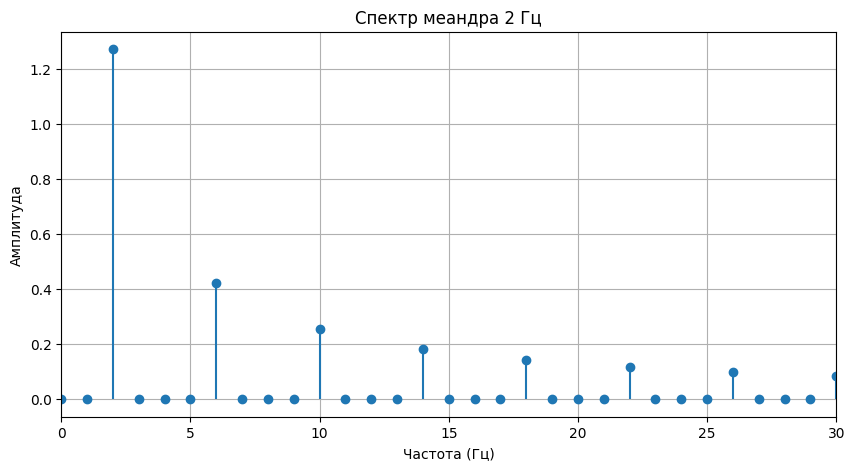

Гармоника | Частота (Гц) | Теоретическая амплитуда | Из спектра
       1 |          2.0 |                  1.273 | 1.273
       3 |          6.0 |                  0.424 | 0.424
       5 |         10.0 |                  0.255 | 0.255
       7 |         14.0 |                  0.182 | 0.182


In [6]:
f_meandr = 2
meandr = signal.square(2 * np.pi * f_meandr * t)

# БПФ
X_meander = np.fft.fft(meandr)

half = N // 2
freq_pos = freq[:half]

# амплитудный спектр
X_meander_mag = np.abs(X_meander[:half]) / half

plt.figure(figsize=(10,5))
plt.stem(freq_pos, X_meander_mag, basefmt=" ")
plt.title('Спектр меандра 2 Гц')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 30)
plt.grid(True)
plt.show()

# первые несколько нечётных гармоник
harmonics = [1, 3, 5, 7]

print("Гармоника | Частота (Гц) | Теоретическая амплитуда | Из спектра")

for k in harmonics:
    f = k * f_meandr
    idx = np.argmin(np.abs(freq_pos - f))  # индекс ближайшей частоты

    A_theory = 4 / (np.pi * k)
    A_fft = X_meander_mag[idx]

    print(f"{k:8d} | {f:12.1f} | {A_theory:22.3f} | {A_fft:.3f}")


**Вопрос 5:** Почему в спектре меандра присутствуют только нечётные гармоники? Покажите, что амплитуды гармоник совпадают с теоретическим значением.

В спектре присутствуют только нечётные гармоники, поскольку {сигнал меандра в течение второй половины периода равен первому, но с противоположным знаком. Из-за такой симметрии чётные гармоники взаимно компенсируются, поэтому в разложении Фурье остаются только нечётные гармоники.}

Вычислим теоретические амплитуды нескольких первых гармоник: {1-я гармоника: амплитуда 1.273 3-я гармоника: амплитуда 0.424 5-я гармоника: амплитуда 0.255 7-я гармоника: амплитуда 0.182}

При численном вычислении Фурье-преобразования получились следующие значения амплитуд гармоник: {1.273, 0.424, 0.255 и 0.182 для частот 2 Гц, 6 Гц, 10 Гц и 14 Гц соответсвенно}

Видим, что результаты вычислений совпадают с теоретическими значениями.

## Часть 3. Дискретизация и алиасинг

### 3.1. Корректная и некорректная дискретизация

Создайте «аналоговый» сигнал — синусоиду частотой 8 Гц, но с очень высокой частотой дискретизации (например, 1000 Гц), чтобы он выглядел гладким.

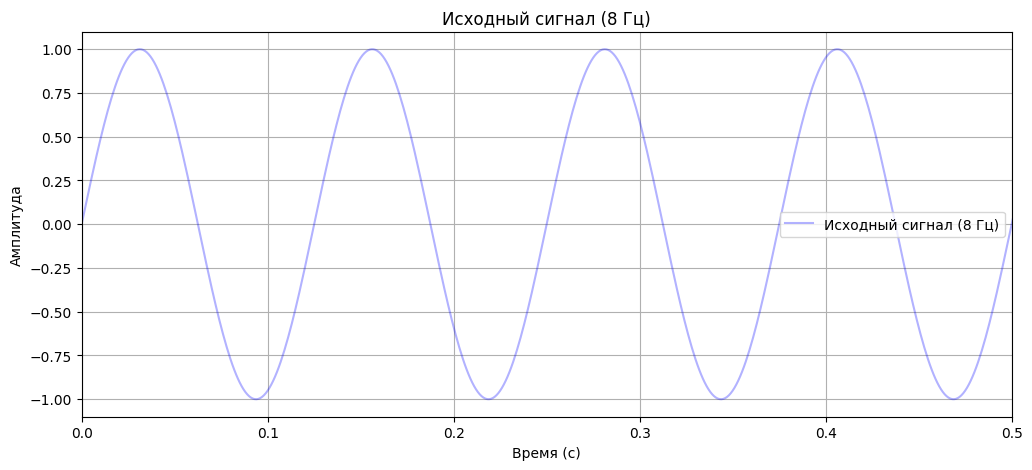

In [7]:


# «Аналоговый» сигнал с высокой частотой дискретизации
fs_analog = 1000
t_analog = np.arange(0, 1, 1/fs_analog)

f_signal = 8
analog_signal = np.sin(2 * np.pi * f_signal * t_analog)

plt.figure(figsize=(12,5))
plt.plot(t_analog, analog_signal, 'b-', alpha=0.3, label='Исходный сигнал (8 Гц)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Исходный сигнал (8 Гц)')
plt.legend()
plt.grid(True)
plt.xlim(0, 0.5)
plt.show()

Теперь выполните его дискретизацию с двумя разными частотами:
- $f_{s1} = 50$ Гц (заведомо больше удвоенной частоты сигнала, 2·8=16 Гц);
- $f_{s2} = 12$ Гц (меньше 16 Гц).

Для этого создайте новые временные оси с шагом $1/f_{s1}$ и $1/f_{s2}$ и вычислите значения синусоиды в этих точках.

На одном графике изобразите:
- исходный гладкий сигнал (тонкая линия);
- отсчёты при корректной дискретизации (маркеры);
- отсчёты при алиасинге (маркеры другого цвета).

Также постройте сигнал, который «воспринимается» после дискретизации с малой частотой.

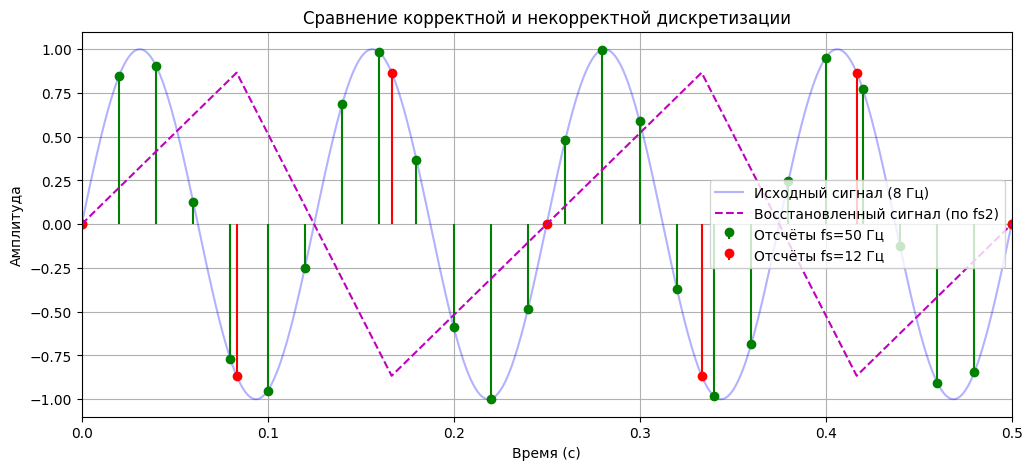

In [8]:


# Частоты дискретизации для эксперимента
fs1 = 50
fs2 = 12

# Отсчёты при корректной дискретизации
t1 = np.arange(0, 1, 1/fs1)
samples1 = np.sin(2 * np.pi * f_signal * t1)

# Отсчёты при некорректной дискретизации (алиасинг)
t2 = np.arange(0, 1, 1/fs2)
samples2 = np.sin(2 * np.pi * f_signal * t2)

# Частота алиасинга
f_alias = abs(f_signal - round(f_signal/fs2)*fs2)

# сигнал, который "кажется" после алиасинга
alias_signal = np.sin(2 * np.pi * f_alias * t_analog)

plt.figure(figsize=(12,5))
plt.plot(t_analog, analog_signal, 'b-', alpha=0.3, label='Исходный сигнал (8 Гц)')
plt.stem(t1, samples1, linefmt='g-', markerfmt='go', basefmt=' ', label=f'Отсчёты fs={fs1} Гц')
plt.stem(t2, samples2, linefmt='r-', markerfmt='ro', basefmt=' ', label=f'Отсчёты fs={fs2} Гц')
plt.plot(t2, np.sin(2 * np.pi * f_alias * t2), 'm--', label='Восстановленный сигнал (по fs2)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Сравнение корректной и некорректной дискретизации')
plt.legend()
plt.grid(True)
plt.xlim(0, 0.5)
plt.show()

**Вопрос 6:** Какая частота «кажется» присутствующей в сигнале при $f_{s2}=12$ Гц? Совпадает ли она с предсказанной теоретически? (Подсказка: формула алиасинга $f_{alias} = |f - k f_s|$, выберите $k$ так, чтобы $f_{alias}$ лежала в интервале $[0, f_s/2]$.)

В сигнале при $f_{s2}=12$ Гц кажется, что присутствует частота {4 Гц}. Она {совпадает} с теоретической: $f_{alias} = |f - k f_s| =${4} при $k=${1}

### 3.2. Интерактивная демонстрация алиасинга

Используя `ipywidgets.interact`, создайте интерактивный график, где можно менять частоту сигнала и частоту дискретизации ползунками, и сразу видеть исходный сигнал, отсчёты и восстановленный сигнал. Пример такого кода был на лекции.

Добейтесь, чтобы при нарушении условия Найквиста явно проявлялся алиасинг (восстановленный сигнал имел более низкую частоту, чем исходный).

In [11]:
def plot_aliasing(f_signal, f_sampling):

    # "аналоговый" сигнал
    fs_analog = 1000
    t = np.arange(0, 1, 1/fs_analog)
    analog = np.sin(2*np.pi*f_signal*t)

    # дискретизация
    t_samples = np.arange(0, 1, 1/f_sampling)
    samples = np.sin(2*np.pi*f_signal*t_samples)

    # частота алиасинга
    k = round(f_signal / f_sampling)
    f_alias = f_signal - k*f_sampling

    alias_signal = np.sin(2*np.pi*f_alias*t)

    plt.figure(figsize=(12,4))
    plt.plot(t, analog, 'b-', alpha=0.3, label='Исходный сигнал')
    plt.stem(t_samples, samples, linefmt='r-', markerfmt='ro', basefmt=' ', label='Отсчёты')
    plt.plot(t, alias_signal, 'm--', label='Восстановленный сигнал')

    plt.xlabel('Время (с)')
    plt.ylabel('Амплитуда')
    plt.title(f'Частота сигнала = {f_signal} Гц, fs = {f_sampling} Гц')
    plt.legend()
    plt.grid(True)
    plt.xlim(0, 0.5)
    plt.show()


widgets.interact(
    plot_aliasing,
    f_signal=widgets.FloatSlider(min=1, max=20, step=0.5, value=8),
    f_sampling=widgets.FloatSlider(min=5, max=40, step=1, value=20)
);

interactive(children=(FloatSlider(value=8.0, description='f_signal', max=20.0, min=1.0, step=0.5), FloatSlider…

**Вопрос 7:** При каких соотношениях частоты сигнала и частоты дискретизации алиасинг наиболее заметен? Что происходит, когда частота сигнала в точности равна половине частоты дискретизации?

Алиасинг наиболее заметен, когда {частота сигнала превышает половину частоты дискретизации, то есть нарушается условие Найквиста}.

Когда частота сигнала в точности равна половине частоты дискретизации, то {выполняется граничный случай теоремы Найквиста. В этом случае отсчёты попадают в одинаковые точки синусоиды и сигнал становится плохо различимым (может выглядеть как чередование одинаковых значений или почти постоянный сигнал), поэтому корректное восстановление становится невозможным.}.